---
tags: [tutorial]
---

# 古典制御フローパターン

量子回路の構造は古典制御フローに依存することが多くあります。量子ビットのイテレーション、グラフのエッジに基づくゲート適用、ゲート列の条件分岐などです。Qamomileでは`qmc.range`、`qmc.items`、`if`分岐、`while`ループでこれらをサポートしています。

この章では以下を扱います：

- `qmc.range()`によるループ
- `qmc.items()`による辞書のイテレーション
- 測定結果に対する`if` / `while`による回路途中の分岐

In [1]:
# 最新のQamomileをpipからインストールします！
# !pip install qamomile

In [2]:
import os

import qamomile.circuit as qmc
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()

## `qmc.range`ループ

`qmc.range`は`start`、`stop`、`step`を引数に取ることができます。ここでは偶数番目の量子ビットにHゲートを適用し、隣接ペアをCXでエンタングルする量子カーネルを作ってみます。

In [3]:
@qmc.qkernel
def hadamard_chain(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, name="q")

    # 偶数番目の量子ビットに H を適用
    for i in qmc.range(0, n, 2):
        q[i] = qmc.h(q[i])

    # 隣接するペアをエンタングル
    for i in qmc.range(n - 1):
        q[i], q[i + 1] = qmc.cx(q[i], q[i + 1])

    return qmc.measure(q)

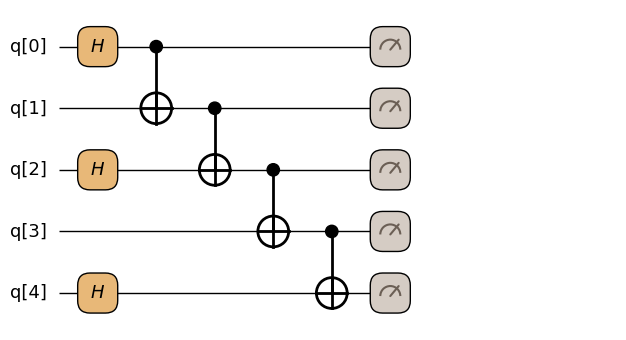

In [4]:
hadamard_chain.draw(n=5, fold_loops=False)

:::{note}
`qmc.range`のループ変数は**単一の変数**でなければなりません（例：`for i in qmc.range(n)`）。
`for [i, j] in qmc.range(n)` のようなタプル・リストのアンパックはサポートされておらず、`SyntaxError`が発生します。
:::

## `qmc.items`によるスパースな相互作用データの処理

QAOAやVQEなど多くの量子アルゴリズムでは、グラフや相互作用マップで決まる特定の量子ビットペアにのみゲートを適用します。全ペアをループするのではなく、相互作用の**辞書**を渡して`qmc.items()`でイテレーションできます。

辞書型にはQamomileのシンボリック型を使います：`qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float]` — キーが量子ビットインデックスのペア、値が相互作用の重みです。

In [5]:
@qmc.qkernel
def sparse_coupling(
    n: qmc.UInt,
    edges: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    gamma: qmc.Float,
) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, name="q")

    # 初期重ね合わせ
    for i in qmc.range(n):
        q[i] = qmc.h(q[i])

    # 指定されたエッジにのみ RZZ 相互作用を適用
    for (i, j), weight in qmc.items(edges):
        q[i], q[j] = qmc.rzz(q[i], q[j], gamma * weight)

    return qmc.measure(q)

:::{note}
`qmc.items`は以下のループパターンをサポートしています：

- `for key, value in qmc.items(d)` — スカラーキー
- `for (i, j), value in qmc.items(d)` — タプルキー
- `for key, value in d.items()` — メソッド呼び出し形式

**value**側は単一の変数でなければなりません。value位置でのタプルアンパック
（例：`for _, (i, j) in qmc.items(d)`）は**サポートされておらず**、`SyntaxError`が発生します。
同様に、`for pair in qmc.items(d)` のような単一ターゲットパターンもサポートされていません。
:::

## `transpiler.to_circuit()`による確認

`draw()`は全パターン（特に複雑な型を伴う`items`、`if`、`while`）にはまだ対応していません。そのような場合は`transpiler.to_circuit()`で全パラメータをバインドした後のトランスパイル済みの回路を確認してください。

In [6]:
edge_data = {(0, 1): 1.0, (1, 2): -0.7, (0, 2): 0.3}

circuit = transpiler.to_circuit(
    sparse_coupling,
    bindings={"n": 3, "edges": edge_data, "gamma": 0.4},
)
print(circuit)

     ┌───┐                                    ┌─┐   
q_0: ┤ H ├─■─────────────────────■────────────┤M├───
     ├───┤ │ZZ(0.4)              │         ┌─┐└╥┘   
q_1: ┤ H ├─■─────────■───────────┼─────────┤M├─╫────
     ├───┤           │ZZ(-0.28)  │ZZ(0.12) └╥┘ ║ ┌─┐
q_2: ┤ H ├───────────■───────────■──────────╫──╫─┤M├
     └───┘                                  ║  ║ └╥┘
c: 3/═══════════════════════════════════════╩══╩══╩═
                                            1  0  2 


`edge_data`の3つのエッジのみがRZZゲートを生成します。

## `if`分岐と`while`ループ

Qamomileは**回路途中での測定**に続く古典分岐をサポートしています。条件は**測定結果**（`Bit`）でなければならず、量子カーネルの引数は使えません。

これはハードウェアレベルの条件付き実行に直接対応します：量子ビットを測定し、その結果に基づいて次の操作を決定します。

### 測定結果に対する`if`

よくあるパターンとして、ある量子ビットを測定し、その結果に基づいて別の量子ビットにゲートを条件付きで適用します。

In [7]:
@qmc.qkernel
def conditional_flip() -> qmc.Bit:
    q0 = qmc.qubit("q0")
    q1 = qmc.qubit("q1")

    q0 = qmc.x(q0)  # |1⟩ を準備
    bit = qmc.measure(q0)

    # q0 の測定結果に基づいて q1 を条件付きで反転
    if bit:
        q1 = qmc.x(q1)
    else:
        pass

    return qmc.measure(q1)

これはQiskitの`if_else`命令にトランスパイルされ、実行できます:

In [8]:
exe = transpiler.transpile(conditional_flip)
if os.environ.get("QAMOMILE_DOCS_TEST") == "1":
    print("docs test mode では dynamic circuit の実行を省略します。")
else:
    executor = transpiler.executor()
    job = exe.sample(executor, bindings={}, shots=100)
    result = job.result()
    for value, count in result.results:
        print(f"  bit={value}: {count} shots")

  bit=1: 100 shots


`q0`は |1⟩ として準備されているため、測定結果は常に1となり、`q1`は常に反転されます。全てのショットで1が返るはずです。

### 測定結果に対する`while`

`while`ループは測定条件がfalseになるまで繰り返します。これはrepeat-until-successプロトコルに有用です。

In [9]:
@qmc.qkernel
def repeat_until_zero() -> qmc.Bit:
    q = qmc.qubit("q")
    q = qmc.h(q)  # |0⟩ か |1⟩ が 50/50 の確率
    bit = qmc.measure(q)

    while bit:
        # 0 が得られるまで再準備と再測定を繰り返す
        q = qmc.qubit("q2")
        q = qmc.h(q)
        bit = qmc.measure(q)

    return bit

これはQiskitの`while_loop`命令にトランスパイルされます。生成された回路構造を確認できます:

In [10]:
exe_while = transpiler.transpile(repeat_until_zero)
qc_while = exe_while.compiled_quantum[0].circuit
print(qc_while)

     ┌───┐┌─┐                             
q_0: ┤ H ├┤M├─────────────────────────────
     └───┘└╥┘┌───────── ┌───┐┌─┐ ───────┐ 
q_1: ──────╫─┤ While-0  ┤ H ├┤M├  End-0 ├─
           ║ └────╥──── └───┘└╥┘ ───────┘ 
           ║ ┌────╨────┐      ║           
c: 1/══════╩═╡ c_0=0x1 ╞══════╩═══════════
           0 └─────────┘      0           


### `if`と`while`の組み合わせ

両方のパターンを組み合わせることができます。以下は測定を繰り返し行い、条件付きで補正ゲートを適用するプロトコルです:

In [11]:
@qmc.qkernel
def measure_and_correct() -> qmc.Bit:
    q0 = qmc.qubit("q0")
    q1 = qmc.qubit("q1")

    q0 = qmc.h(q0)
    bit = qmc.measure(q0)

    while bit:
        # bit が 1 なら q1 に補正を適用
        if bit:
            q1 = qmc.x(q1)
        else:
            q1 = q1
        # 再準備と再測定
        q0 = qmc.qubit("q0_retry")
        q0 = qmc.h(q0)
        bit = qmc.measure(q0)

    return qmc.measure(q1)

In [12]:
exe_combined = transpiler.transpile(measure_and_correct)
qc_combined = exe_combined.compiled_quantum[0].circuit
print(qc_combined)

     ┌───┐┌─┐                                                                 »
q_0: ┤ H ├┤M├─────────────────────────────────────────────────────────────────»
     └───┘└╥┘┌─────────        ┌──────  ┌───┐┌────────  ───────┐     ───────┐ »
q_1: ──────╫─┤          ───────┤ If-1  ─┤ X ├┤ Else-1    End-1 ├────        ├─»
           ║ │ While-0  ┌───┐  └──╥───  └───┘└────────  ───────┘ ┌─┐  End-0 │ »
q_2: ──────╫─┤          ┤ H ├─────╫──────────────────────────────┤M├        ├─»
           ║ └────╥──── └───┘     ║                              └╥┘ ───────┘ »
           ║ ┌────╨────┐     ┌────╨────┐                          ║           »
c: 3/══════╩═╡ c_0=0x1 ╞═════╡ c_0=0x1 ╞══════════════════════════╩═══════════»
           0 └─────────┘     └─────────┘                          0           »
«        
«q_0: ───
«     ┌─┐
«q_1: ┤M├
«     └╥┘
«q_2: ─╫─
«      ║ 
«c: 3/═╩═
«      2 


## まとめ

- `qmc.range(n)`でシンボリック範囲のループ。
- `qmc.items(dict)`でスパースなキーバリューデータ（エッジ、重み）のイテレーション。
- `if bit:` / `while bit:`で**測定結果**に基づく分岐。両分岐で同じ量子ビットハンドルを扱う必要があります（アフィンルール）。
- これらの制御フローは対象の量子SDKのネイティブな命令（例：Qiskitの`if_else`や`while_loop`）にトランスパイルされます。

**次へ**：[再利用パターン](06_reuse_patterns.ipynb) — ヘルパー量子カーネル、コンポジットゲート、スタブゲート。